In [1]:
import math
import matplotlib.pyplot as plt

In [2]:
def A(y):
    return 2*y + y**2

def P(y):
    return 2 + 2*math.sqrt(1 + y**2)

def f(y):
    Q = 1.2
    g = 9.81
    L = 15.0
    term1 = math.sqrt(2 * g / L)
    term2 = (A(y) / P(y))**1.5
    term3 = Q / A(y)
    return term1 * term2 - term3

In [3]:
def bisection(xl, xu, tol):
    if f(xl) * f(xu) >= 0:
        print("Bisection method fails.")
        return 0

    print(f"{'Iter':<8}{'xl':<12}{'xu':<12}{'xr':<12}{'f(xr)':<15}{'ea (%)':<15}")
    print("-" * 75)

    it = 0
    xr_old = xl
    errors = []
    iters = []

    while it <= 12:
        it += 1
        xr = (xl + xu) / 2
        
        if it == 1:
            ea_str = "N/A"
            print(f"{it:<8}{xl:<12.6f}{xu:<12.6f}{xr:<12.6f}{f(xr):<15.6f}{ea_str:<15}")
        else:
            ea = abs((xr - xr_old) / xr) * 100
            errors.append(ea)
            iters.append(it)
            print(f"{it:<8}{xl:<12.6f}{xu:<12.6f}{xr:<12.6f}{f(xr):<15.6f}{ea:<15.6f}")

            if f(xr) == 0 or ea <= tol:
                break

        if f(xl) * f(xr) < 0:
            xu = xr
        else:
            xl = xr

        xr_old = xr

    plt.figure()
    plt.plot(iters, errors, marker='o')
    plt.xlabel('Iteration')
    plt.ylabel('Error (%)')
    plt.title('Convergence of Error in Bisection Method')
    plt.grid(True)
    plt.show()

    return xr

Iter    xl          xu          xr          f(xr)          ea (%)         
---------------------------------------------------------------------------
1       0.300000    1.500000    0.900000    0.014914       N/A            
2       0.300000    0.900000    0.600000    -0.522115      50.000000      
3       0.600000    0.900000    0.750000    -0.226943      20.000000      
4       0.750000    0.900000    0.825000    -0.101456      9.090909       
5       0.825000    0.900000    0.862500    -0.042310      4.347826       
6       0.862500    0.900000    0.881250    -0.013477      2.127660       
7       0.881250    0.900000    0.890625    0.000772       1.052632       
8       0.881250    0.890625    0.885938    -0.006339      0.529101       
9       0.885938    0.890625    0.888281    -0.002780      0.263852       


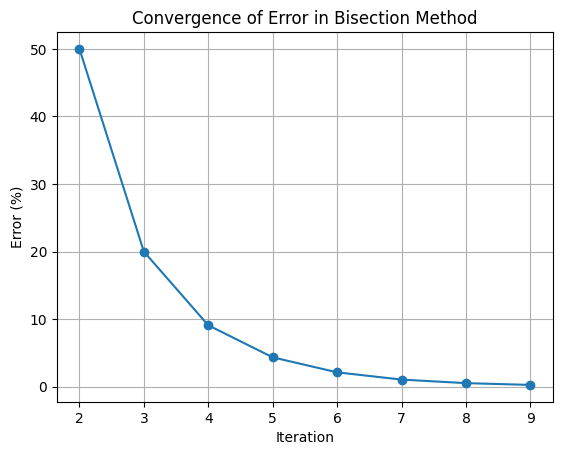


flow depth y: 0.888281



In [4]:
xl, xu = 0.3, 1.5
tol = 0.5

root = bisection(xl, xu, tol)
print(f"\nflow depth y: {root:.6f}\n")